Epoch 1/100 | Train Loss: 1.6585 | Val Loss: 1.6588
Epoch 2/100 | Train Loss: 1.6456 | Val Loss: 1.6979
Epoch 3/100 | Train Loss: 1.6539 | Val Loss: 1.7243
Epoch 4/100 | Train Loss: 1.6642 | Val Loss: 1.4693
Epoch 5/100 | Train Loss: 1.6261 | Val Loss: 1.6693
Epoch 6/100 | Train Loss: 1.5929 | Val Loss: 1.7290
Epoch 7/100 | Train Loss: 1.6435 | Val Loss: 1.8258
Epoch 8/100 | Train Loss: 1.6279 | Val Loss: 1.6390
Epoch 9/100 | Train Loss: 1.6224 | Val Loss: 1.6119
Epoch 10/100 | Train Loss: 1.6268 | Val Loss: 1.6406
Epoch 11/100 | Train Loss: 1.6331 | Val Loss: 1.6564
Epoch 12/100 | Train Loss: 1.6523 | Val Loss: 1.4016
Epoch 13/100 | Train Loss: 1.6328 | Val Loss: 1.8059
Epoch 14/100 | Train Loss: 1.6735 | Val Loss: 1.5842
Epoch 15/100 | Train Loss: 1.5945 | Val Loss: 1.7849
Epoch 16/100 | Train Loss: 1.6850 | Val Loss: 1.4691
Epoch 17/100 | Train Loss: 1.6285 | Val Loss: 1.6445
Epoch 18/100 | Train Loss: 1.6040 | Val Loss: 1.5787
Epoch 19/100 | Train Loss: 1.6354 | Val Loss: 1.5151
Ep

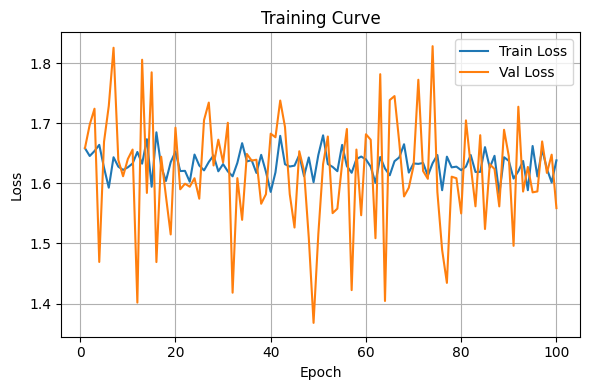

In [1]:
# ==============================
# Dependencies
# ==============================
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Config
# ==============================
class HamburgMambaConfig:
    def __init__(self):
        self.d_model = 128  # hidden size / model width
        self.num_crisis_levels = 5
        self.input_features = []  # to be filled after df creation

# ==============================
# Mamba Backbone Placeholder
# ==============================
class MambaBackbonePlaceholder(nn.Module):
    """
    Lightweight stand-in for a future Mamba-style backbone.
    """
    def __init__(self, d_model, nhead=4, num_layers=1, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.input_proj = nn.Linear(d_model, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dropout=dropout
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, seq_len, feature_dim)
        if x.shape[-1] != self.d_model:
            x = self.input_proj(x)
        x = self.encoder(x)
        x = self.norm(x)
        return x  # (batch, seq_len, d_model)

# ==============================
# Hybrid Model with switchable backbone and optional 4D path
# ==============================
class HybridSafetyModel(nn.Module):
    def __init__(self, config, backbone_type="gru", use_4d=False):
        super().__init__()
        self.config = config
        self.backbone_type = backbone_type
        self.use_4d = use_4d
        self.hidden_size = config.d_model

        if backbone_type == "gru":
            self.rnn = nn.GRU(
                input_size=len(self.config.input_features),
                hidden_size=self.hidden_size,
                batch_first=True
            )
            self.backbone = None
        else:  # placeholder for Mamba-like
            self.rnn = None
            self.backbone = MambaBackbonePlaceholder(d_model=self.hidden_size)

        # Prediction heads
        self.classifier = nn.Linear(self.hidden_size, config.num_crisis_levels)
        self.burnout = nn.Linear(self.hidden_size, 1)
        self.retention = nn.Linear(self.hidden_size, 1)
        self.response_delay = nn.Linear(self.hidden_size, 1)

    def forward(self, batch):
        # Build feature tensor: (batch, seq_len, feature_dim)
        features = [
            batch[key].float().unsqueeze(-1)
            for key in self.config.input_features
        ]
        x = torch.cat(features, dim=-1)  # (batch, seq_len, feature_dim)

        if self.use_4d:
            # Example 4D expansion placeholder: add a dummy dim and collapse back
            x = x.unsqueeze(-1)  # (batch, seq_len, feature_dim, 1)
            x = x.permute(0, 2, 1, 3)  # (batch, feature_dim, seq_len, 1)
            x = x.squeeze(-1).transpose(1, 2)  # (batch, seq_len, feature_dim)

        if self.backbone_type == "gru":
            x, _ = self.rnn(x)  # (batch, seq_len, hidden)
        else:
            x = self.backbone(x)  # (batch, seq_len, hidden)

        x_last = x[:, -1, :]  # last timestep

        return {
            'crisis_logits': self.classifier(x_last),
            'burnout': torch.sigmoid(self.burnout(x_last)).squeeze(-1),
            'retention': torch.sigmoid(self.retention(x_last)).squeeze(-1),
            'response_delay': torch.relu(self.response_delay(x_last)).squeeze(-1)
        }

# ==============================
# Dataset (fixed: no extra leading dimension)
# ==============================
class HamburgSafetyDataset(Dataset):
    def __init__(self, dataframe, config, seq_len=32):
        self.df = dataframe.reset_index(drop=True)
        self.config = config
        self.seq_len = seq_len
        self.features = list(config.input_features)

    def __len__(self):
        return len(self.df) // self.seq_len

    def __getitem__(self, idx):
        start = idx * self.seq_len
        end = start + self.seq_len
        chunk = self.df.iloc[start:end]

        sample = {}
        for key in self.features:
            if key == 'chief_complaint_encoded' or key.endswith('_level'):
                sample[key] = torch.tensor(chunk[key].values, dtype=torch.long)  # (seq_len,)
            else:
                sample[key] = torch.tensor(chunk[key].values, dtype=torch.float32)  # (seq_len,)

        return sample  # each is (seq_len,) so later unsqueeze(-1) gives correct 3D

# ==============================
# Training Loop with validation and gradient monitoring
# ==============================
def train_model(model, dataloader, optimizer, criterion, device, num_epochs=100, val_split=0.1):
    history = {'train_loss': [], 'val_loss': []}
    total_batches = len(dataloader)
    val_batches = max(1, int(total_batches * val_split))
    train_cutoff = total_batches - val_batches

    for epoch in range(num_epochs):
        model.train()
        train_loss_accum = 0.0
        for i, batch in enumerate(dataloader):
            for k in batch:
                batch[k] = batch[k].to(device)

            optimizer.zero_grad()
            outputs = model(batch)
            # synthetic classification target
            batch_size = batch['age'].shape[0]
            crisis_targets = torch.randint(0, model.config.num_crisis_levels, (batch_size,), device=device)

            loss = criterion(outputs['crisis_logits'], crisis_targets)
            loss += torch.mean((outputs['burnout'] - 0.5) ** 2)
            loss += torch.mean((outputs['retention'] - 0.5) ** 2)
            loss += torch.mean(outputs['response_delay'] ** 2)

            loss.backward()

            # gradient norm (optional logging)
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            # print(f"[Epoch {epoch+1} batch {i+1}] grad norm: {total_norm:.4f}")

            optimizer.step()
            train_loss_accum += loss.item()

        avg_train_loss = train_loss_accum / total_batches
        history['train_loss'].append(avg_train_loss)

        # validation
        model.eval()
        val_loss_accum = 0.0
        count = 0
        with torch.no_grad():
            for j, batch in enumerate(dataloader):
                if j >= train_cutoff:
                    for k in batch:
                        batch[k] = batch[k].to(device)
                    outputs = model(batch)
                    batch_size = batch['age'].shape[0]
                    crisis_targets = torch.randint(0, model.config.num_crisis_levels, (batch_size,), device=device)

                    l = criterion(outputs['crisis_logits'], crisis_targets)
                    l += torch.mean((outputs['burnout'] - 0.5) ** 2)
                    l += torch.mean((outputs['retention'] - 0.5) ** 2)
                    l += torch.mean(outputs['response_delay'] ** 2)

                    val_loss_accum += l.item()
                    count += 1
        avg_val_loss = val_loss_accum / count if count > 0 else None
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return history

# ==============================
# Synthetic Data Generator
# ==============================
def generate_synthetic_data(num_samples=2048):
    data = {
        'vital_heart_rate': np.random.normal(80, 10, num_samples),
        'vital_bp_systolic': np.random.normal(120, 15, num_samples),
        'vital_bp_diastolic': np.random.normal(80, 10, num_samples),
        'vital_respiratory_rate': np.random.normal(16, 2, num_samples),
        'vital_oxygen_saturation': np.random.normal(98, 1, num_samples),
        'vital_temperature': np.random.normal(37, 0.5, num_samples),
        'vital_gcs': np.clip(np.random.normal(15, 1, num_samples), 3, 15),
        'age': np.random.randint(20, 90, num_samples),
        'gender': np.random.randint(0, 2, num_samples),
        'hospital_destination': np.random.randint(0, 6, num_samples),
        'acuity_level': np.random.randint(0, 5, num_samples),
        'system_crisis_level': np.random.randint(0, 5, num_samples),
        'crew_calls_today': np.random.randint(0, 25, num_samples),
        'crew_hours_on_shift': np.random.uniform(0, 12, num_samples),
        'crew_fatigue_level': np.random.uniform(0, 2, num_samples),
        'burnout_risk_score': np.random.rand(num_samples),
        'available_crews': np.random.randint(0, 80, num_samples),
        'calls_waiting': np.random.randint(0, 10, num_samples),
        'response_delay_minutes': np.random.rand(num_samples) * 30,
        'handoff_quality_score': np.random.rand(num_samples),
        'documentation_completeness': np.random.rand(num_samples),
        'hour': np.random.randint(0, 24, num_samples),
        'day_of_week': np.random.randint(0, 7, num_samples),
        'shift_change_stress': np.random.rand(num_samples),
        'weather_impact': np.random.rand(num_samples) * 0.4 + 0.8,
        'tourism_factor': np.random.rand(num_samples) * 0.2 + 0.9,
        'chief_complaint_encoded': np.random.randint(0, 20, num_samples)
    }
    return pd.DataFrame(data)

# ==============================
# Plot utility
# ==============================
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(6,4))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    if history['val_loss'][0] is not None:
        plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ==============================
# Main
# ==============================
def main():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Data
    df = generate_synthetic_data(num_samples=2048)

    # Config
    config = HamburgMambaConfig()
    config.input_features = df.columns.tolist()

    # Dataset + loader
    dataset = HamburgSafetyDataset(df, config, seq_len=32)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

    # Model (GRU path)
    model = HybridSafetyModel(config, backbone_type="gru", use_4d=False).to(device)
    # To switch to placeholder Mamba path later:
    # model = HybridSafetyModel(config, backbone_type="mamba", use_4d=True).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Train 100 epochs
    history = train_model(model, dataloader, optimizer, criterion, device=device, num_epochs=100, val_split=0.1)

    # Plot
    plot_history(history)

if __name__ == "__main__":
    main()
